# 🔍 Logo Template Matching
**Recognition Tasks | Classical Computer Vision**

---

## 💡 What is Template Matching?

Working at a factory. Products come on a conveyor belt and want to check:
> *"Does this product have company logo printed on it?"*

 already have a small reference image of the logo (called a **template**).

and at each position it asks: *"How similar is this patch to my logo?"*

The spot with the **highest similarity score** = where the logo is. 🎯

---

## 🧮 How is Similarity Measured?

OpenCV gives us several methods. I used **`TM_CCOEFF_NORMED`**:

| Method | Score | Best when |
|---|---|---|
| `TM_SQDIFF` | Lower = better | Exact pixel match |
| `TM_CCORR` | Higher = better | Fast but noisy |
| `TM_CCOEFF_NORMED` | Higher = better (0 to 1) | **Lighting changes, most reliable** |

I used `TM_CCOEFF_NORMED` because real product photos have varying lighting.

---

## ⚠️ Limitations
- ❌ Fails if logo is **rotated or scaled** differently
- ❌ Sensitive to **heavy lighting changes or occlusion**
- ✅ Works great when logo appearance is **consistent**

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 🖼️  Upload  Images


In [18]:
# input image = boxes (search space)
# template   = big amazon logo (resized to fit inside input)

import cv2
import numpy as np
from google.colab import files

# --- Upload images ---
print("Upload INPUT image (the boxes photo):")
uploaded = files.upload()
input_name = list(uploaded.keys())[0]

print("\nUpload TEMPLATE image (the Amazon logo):")
uploaded = files.upload()
template_name = list(uploaded.keys())[0]

# --- Load ---
input_img    = cv2.imread("/content/logo_small (1).jpeg")
template_img = cv2.imread("/content/logo_big (1).jpeg")

# ---


input_rgb  = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)   # boxes → RGB
boxes_rgb  = input_rgb.copy()

# --- Resize template to 25% of input width ---
input_h, input_w = input_img.shape[:2]
target_w = int(input_w * 0.25)
scale    = target_w / template_img.shape[1]
target_h = int(template_img.shape[0] * scale)

# safety: template height must be less than input height
if target_h >= input_h:
    scale    = (input_h * 0.5) / template_img.shape[0]
    target_h = int(template_img.shape[0] * scale)
    target_w = int(template_img.shape[1] * scale)

template_resized = cv2.resize(template_img, (target_w, target_h))

print(f"\n✅ Input size    : {input_w}x{input_h} px")
print(f"✅ Template size : {target_w}x{target_h} px  (scale={scale:.3f})")

Upload INPUT image (the boxes photo):


Saving logo_small.jpeg to logo_small (2).jpeg

Upload TEMPLATE image (the Amazon logo):


Saving logo_big.jpeg to logo_big (2).jpeg

✅ Input size    : 739x251 px
✅ Template size : 184x214 px  (scale=0.154)


## 👀 Step 3 — Visualize Both Images

> 💬 OpenCV loads images in **BGR** order, but Matplotlib expects **RGB**.
>  use `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` to fix the color before displaying.

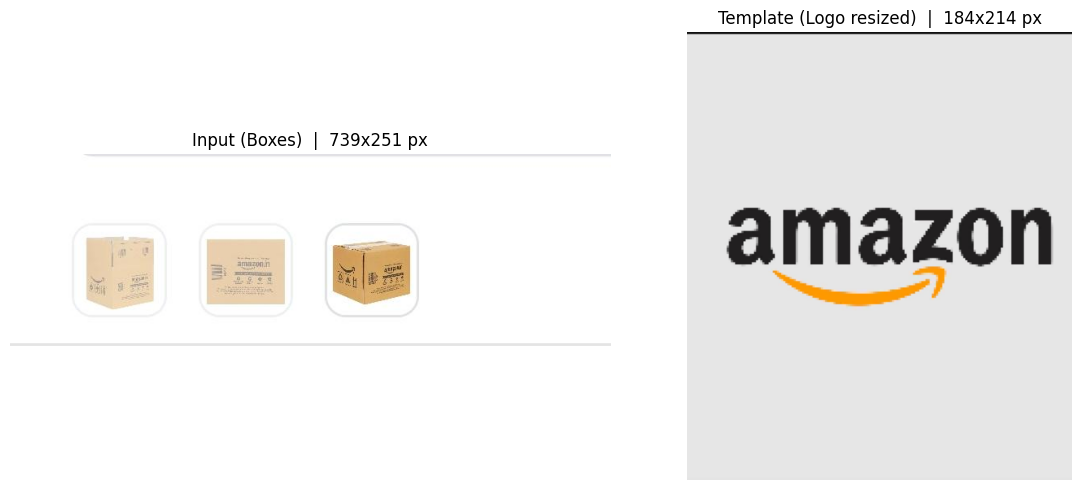

In [22]:
# display them
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(input_rgb)
axes[0].set_title(f"Input (Boxes)  |  {input_img.shape[1]}x{input_img.shape[0]} px", fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(template_resized, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Template (Logo resized)  |  {target_w}x{target_h} px", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## ⚙️ Step 4 — Convert to Grayscale

We convert both images to **grayscale** before matching.

**Why?**
- Template matching compares **pixel intensity values** between patches
- Grayscale = 1 channel → faster computation, less noise from color variation
- We don't need color to find *where* the logo is, just its **shape and structure**

> 💬 `cv2.COLOR_BGR2GRAY` collapses the 3 color channels into a single intensity channel.

In [23]:
input_gray    = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template_resized, cv2.COLOR_BGR2GRAY)

print(f"Input image shape    (original): {input_img.shape}   → (H, W, 3 channels)")
print(f"Input image shape  (grayscale) : {input_gray.shape}   → (H, W)  — 1 channel only")
print(f"Template shape     (grayscale) : {template_gray.shape}")

Input image shape    (original): (251, 739, 3)   → (H, W, 3 channels)
Input image shape  (grayscale) : (251, 739)   → (H, W)  — 1 channel only
Template shape     (grayscale) : (214, 184)


## 🔬 Step 5 — Run Template Matching

**`cv2.matchTemplate(image, template, method)`**

This returns a **result map** — a 2D array where each value represents how well
the template matched at that (x, y) position in the image.

- Result shape = `(H - tH + 1,  W - tW + 1)` — one score per valid sliding position
- With `TM_CCOEFF_NORMED`: score is between **0 and 1** → closer to 1 = better match

**`cv2.minMaxLoc(result)`** finds the location of the best score in the result map.

Template size    : 184 x 214 px
Bounding box     : top-left=(329, 439)  →  bottom-right=(513, 653)


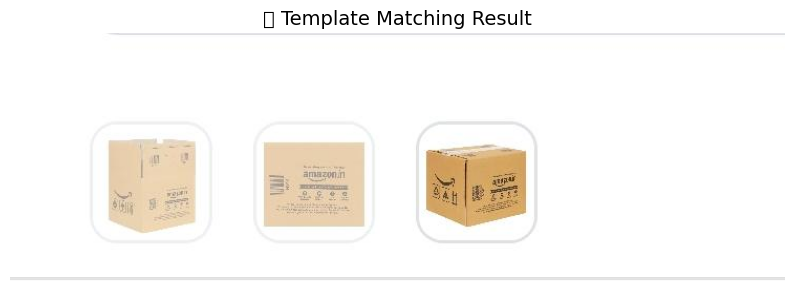

In [24]:
top_left = max_loc

# use template_resized not template
t_height, t_width = template_resized.shape[:2]

bottom_right = (top_left[0] + t_width, top_left[1] + t_height)

print(f"Template size    : {t_width} x {t_height} px")
print(f"Bounding box     : top-left={top_left}  →  bottom-right={bottom_right}")

output = boxes_rgb.copy()
cv2.rectangle(output, top_left, bottom_right, color=(0, 255, 0), thickness=3)

label = f"Logo Found! Score: {max_val:.2f}"
cv2.putText(output, label, (top_left[0], top_left[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(output)
plt.title('✅ Template Matching Result', fontsize=14)
plt.axis('off')
plt.show()

## 📐 Step 6 — Compute Bounding Box & Draw Result

We know the **top-left corner** of the best match from `max_loc`.

To get the **bottom-right corner**, we simply add the template's width and height:

```
bottom_right = (top_left_x + template_width,  top_left_y + template_height)
```

Then we draw a rectangle around that region on the original image.

Template size    : 1195 x 1392 px
Bounding box     : top-left=(329, 439)  →  bottom-right=(1524, 1831)


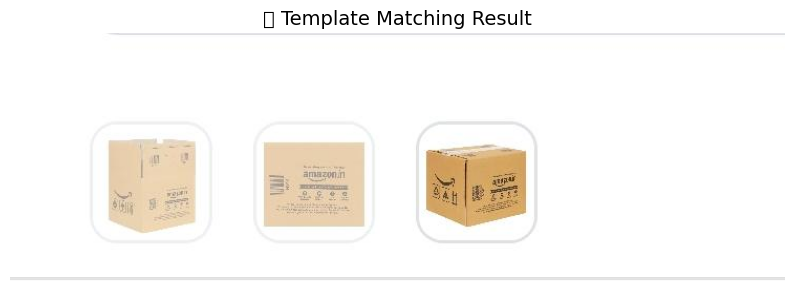

In [25]:
# Top-left corner from the best match location
top_left = max_loc

# Template dimensions
t_height, t_width = template.shape[:2]

# Bottom-right corner
bottom_right = (top_left[0] + t_width, top_left[1] + t_height)

print(f"Template size    : {t_width} x {t_height} px")
print(f"Bounding box     : top-left={top_left}  →  bottom-right={bottom_right}")

# Draw rectangle on a copy of the original RGB image
output = boxes_rgb.copy()
cv2.rectangle(output, top_left, bottom_right, color=(0, 255, 0), thickness=3)

# Add label
label = f"Logo Found! Score: {max_val:.2f}"
cv2.putText(output, label, (top_left[0], top_left[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# Display final result
plt.figure(figsize=(10, 7))
plt.imshow(output)
plt.title('✅ Template Matching Result', fontsize=14)
plt.axis('off')
plt.show()

## 💾 Step 7 — Save & Download Result

> 💬 We save using `cv2.imwrite()` which expects **BGR** format — so we convert back from RGB.

In [26]:
output_bgr = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)
cv2.imwrite('logo_match_result.png', output_bgr)

files.download('logo_match_result.png')
print("✅ Result saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Result saved and downloaded!
